# Hospitalizaciones y defunciones semnales

# Filtrado de los datos

In [1]:
# Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.interpolate import CubicSpline, interp1d, PchipInterpolator, make_interp_spline


casos_sint = casos sintomaticos

In [2]:
df = pd.read_csv("influenza_glm_ready.csv") # Importamos el dataset
influenza = df[['SEMANA_RELATIVA', "CASOS_SINT", "CASOS_HOSP", "CASOS_DEF", 'FLAG_SINT', 'FLAG_HOSP','FLAG_DEF']]
influenza.head() 

,SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF
0,1,134,40,5,observado,observado,observado
1,2,145,62,8,observado,observado,observado
2,3,162,71,9,observado,observado,observado
3,4,125,58,8,observado,observado,observado
4,5,102,49,3,observado,observado,observado


## Inspección de los datos

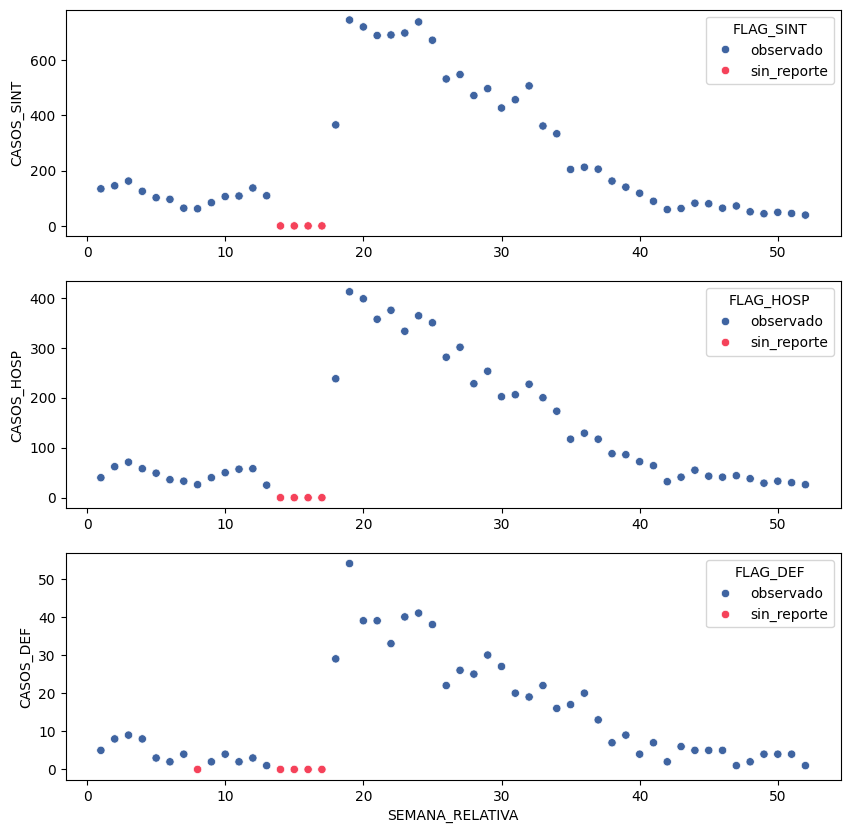

In [3]:
fig, ax = plt.subplots(3, figsize = (10,10))
colors = ['#3f64a1', '#f5425a']
sns.scatterplot(
    data=influenza, 
    x='SEMANA_RELATIVA', 
    y='CASOS_SINT',
    hue='FLAG_SINT',
    palette = colors,
    ax = ax[0]
)
sns.scatterplot(
    data=influenza, 
    x='SEMANA_RELATIVA', 
    y='CASOS_HOSP',
    hue='FLAG_HOSP',
    palette = colors,
    ax = ax[1],
)
sns.scatterplot(
    data=influenza, 
    x='SEMANA_RELATIVA', 
    y='CASOS_DEF',
    hue='FLAG_DEF',
    palette = colors,
    ax = ax[2]
)
ax[0].set_xlabel(None)
ax[1].set_xlabel(None)

plt.show()

## Procesamiento

In [4]:
SintSemanasReporte = []
SintSemanasNoReporte = []
HospSemanasReporte = []
HospSemanasNoReporte = []
DefSemanasReporte = []
DefSemanasNoReporte = []

for i in range (len(df)):
    if influenza["FLAG_SINT"][i] == "observado":
        SintSemanasReporte.append(influenza["SEMANA_RELATIVA"][i])
    else:
        SintSemanasNoReporte.append(influenza["SEMANA_RELATIVA"][i])

    if influenza["FLAG_SINT"][i] == "observado":
        HospSemanasReporte.append(influenza["SEMANA_RELATIVA"][i])
    else:
        HospSemanasNoReporte.append(influenza["SEMANA_RELATIVA"][i])

    if influenza["FLAG_SINT"][i] == "observado":
        DefSemanasReporte.append(influenza["SEMANA_RELATIVA"][i])
    else:
        DefSemanasNoReporte.append(influenza["SEMANA_RELATIVA"][i]) 

In [5]:
interpoladores = {"Spline Cubico": CubicSpline, "Lineal": interp1d, "PCHIP": PchipInterpolator}

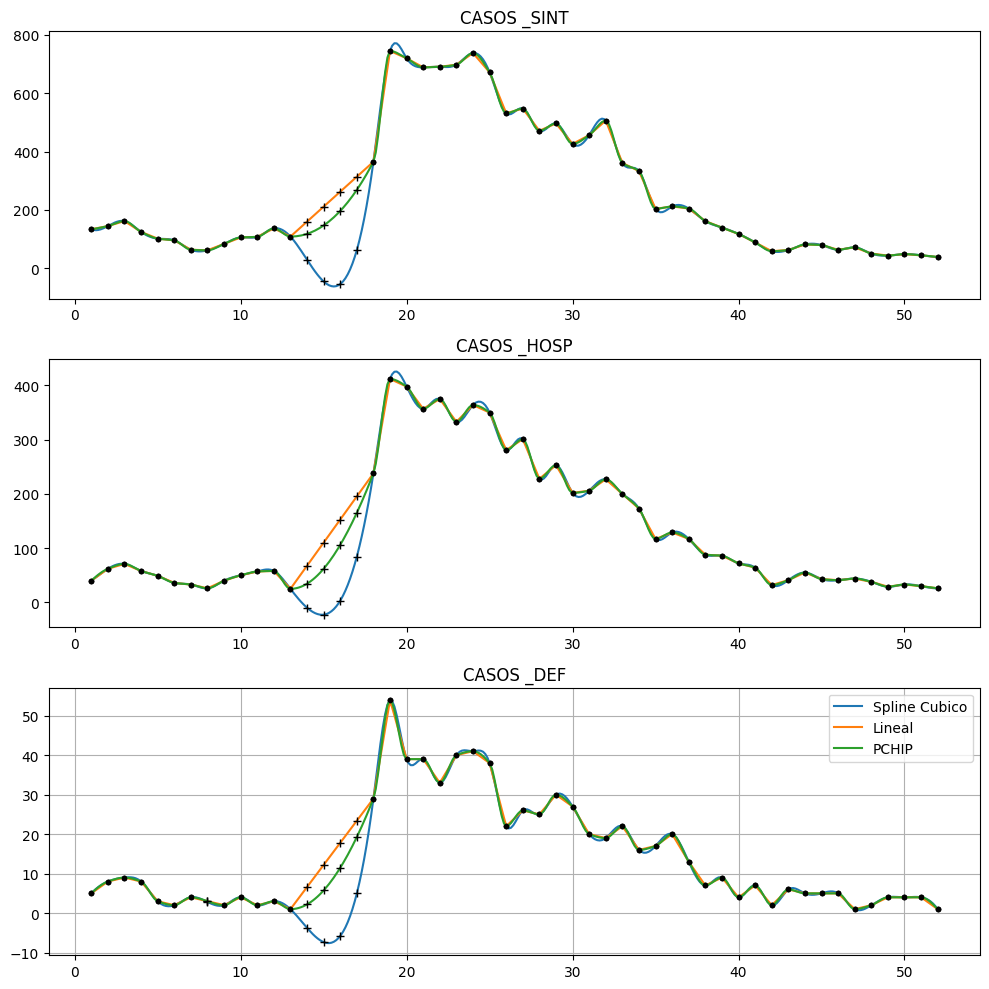

In [88]:
fig, ax = plt.subplots(3, figsize = (10,10))

i = 0
for caso in ["_SINT", "_HOSP", "_DEF"]:
    SemanasReporte = influenza[influenza["FLAG" + caso] == "observado"]["SEMANA_RELATIVA"]
    Casos = influenza[influenza["FLAG" + caso] == "observado"]["CASOS" + caso]
    SemanasSinReporte = influenza[influenza["FLAG" + caso] == "sin_reporte"]["SEMANA_RELATIVA"]

    for f in interpoladores.keys():
        Poly =  interpoladores[f](SemanasReporte, Casos)
        X = np.linspace(1, 52, 7*52)
        Y = Poly(X)
        Imputaciones = Poly(SemanasSinReporte)
        ax[i].plot(X, Y, label=f)
        ax[i].plot(SemanasReporte, Casos, 'k.')
        ax[i].plot(SemanasSinReporte, Imputaciones, 'k+')
    
    ax[i].set_title("CASOS " + caso)

    i += 1

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

Datos Acumulados

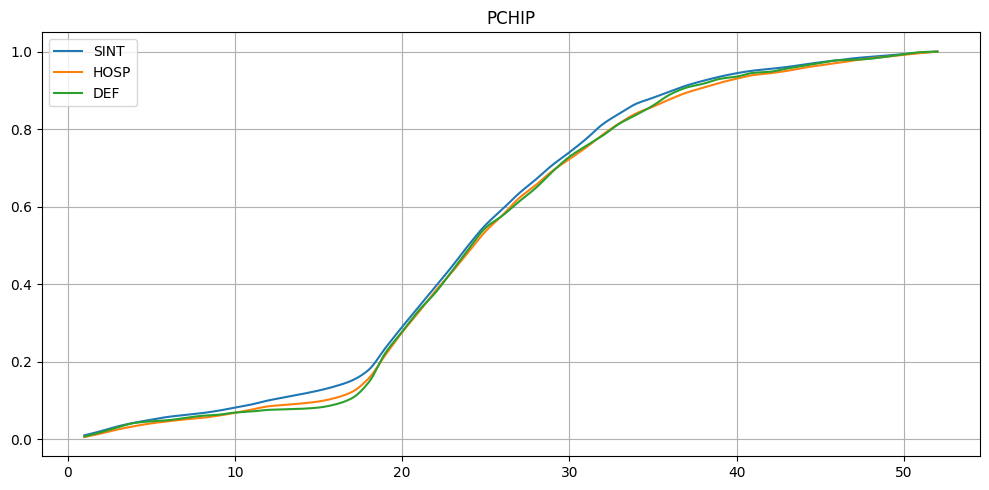

In [87]:
fig, ax = plt.subplots(figsize = (10,5))

for caso in ["SINT", "HOSP", "DEF"]:
    Semanas = influenza["SEMANA_RELATIVA"]
    Casos = influenza["CASOS_" + caso].astype(float)
    CasosObservados = influenza[influenza["FLAG_" + caso] == "observado"]["CASOS_" + caso]
    SemanasReporte = influenza[influenza["FLAG_" + caso] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + caso] == "sin_reporte"]["SEMANA_RELATIVA"]
                                                                              
    Poly = PchipInterpolator(SemanasReporte, CasosObservados)

    Casos[SemanasSinReporte.index] = Poly(SemanasSinReporte.index)
    CasosAcumulados = [Casos[0]]

    for i in range(1, 52):
        CasosAcumulados.append(CasosAcumulados[i-1]+Casos[i])

    CasosAcumulados  = np.array(CasosAcumulados)
    CasosAcumulados = CasosAcumulados / CasosAcumulados[-1]

    PolyAcumulado = PchipInterpolator(Semanas, CasosAcumulados)
    X = np.linspace(1, 52, 7*52)
    Y = PolyAcumulado(X)
    Imputaciones = PolyAcumulado(SemanasSinReporte)
    ax.plot(X, Y, label=caso)
    #ax.plot(SemanasSinReporte, Imputaciones, 'k+')

ax.set_title("PCHIP")
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

Añadir los datos del interpolador

### Sidequest 1
Ajustar con aproximadores macanisticos

### Sidequest 2 

Investigar como predecir un modelo binomial dados cofactores usnado glm

Hacer un glm con una variable binomial para predecir defunciones dado cofactores/predictores: prop_ (proporciones)
p (muerte|covariable) = ?
- Edad, etc